In [2]:
import pandas as pd
import numpy as np

In [3]:
# Load your dataset
file_path = 'cleaned_influencer_data.xlsx'
data = pd.read_excel(file_path)


In [4]:
def remove_outliers_iqr(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)  # First quartile
        Q3 = df[column].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile range

        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter the DataFrame
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df


In [5]:
# List of variables to clean
variables_to_clean = [
    'content_views',
    'engagement_rate',
    'total_engagement',
    'total_impressions',
    'total_paid_media_spend',
    'total_posts',
    'views_per_post'
]

# Remove outliers
cleaned_data = remove_outliers_iqr(data, variables_to_clean)


In [6]:
# Display the cleaned data summary
print(cleaned_data.describe())

       total_engagement  content_views  total_impressions  total_posts  \
count        231.000000     231.000000       2.310000e+02   231.000000   
mean       14299.324675   58347.186147       1.588068e+07    21.952381   
std         8496.628394   27139.818727       9.874057e+06     8.704940   
min         1197.000000    7099.000000       1.574632e+06     4.000000   
25%         7558.500000   37586.000000       8.699704e+06    16.000000   
50%        12365.000000   54647.000000       1.369417e+07    20.000000   
75%        19809.500000   74561.000000       2.103722e+07    27.500000   
max        39168.000000  165520.000000       5.477919e+07    46.000000   

       total_paid_media_spend  engagement_rate  views_per_post  \
count              231.000000       231.000000      231.000000   
mean              9688.943723         0.001081     2727.560066   
std               4625.232757         0.000657      921.030944   
min                950.000000         0.000043     1013.863636   
25%

In [7]:
# Apply log transformation
data['log_content_views'] = np.log1p(data['content_views'])
data['log_engagement_rate'] = np.log1p(data['engagement_rate'])
data['log_total_engagement'] = np.log1p(data['total_engagement'])
data['log_total_impressions'] = np.log1p(data['total_impressions'])
data['log_total_paid_media_spend'] = np.log1p(data['total_paid_media_spend'])
data['log_total_posts'] = np.log1p(data['total_posts'])
data['log_views_per_post'] = np.log1p(data['views_per_post'])

In [8]:
print(data[['log_content_views', 'log_engagement_rate', 'log_total_engagement', 
             'log_total_impressions', 'log_total_paid_media_spend', 
             'log_total_posts', 'log_views_per_post']].describe())


       log_content_views  log_engagement_rate  log_total_engagement  \
count         326.000000           326.000000            326.000000   
mean           11.012313             0.001172              9.496803   
std             0.613230             0.001153              0.813473   
min             8.867850             0.000003              5.953243   
25%            10.599038             0.000467              9.039164   
50%            11.069493             0.000881              9.650432   
75%            11.426266             0.001478             10.085559   
max            13.387327             0.008944             11.253468   

       log_total_impressions  log_total_paid_media_spend  log_total_posts  \
count             326.000000                  326.000000       326.000000   
mean               16.660518                    9.104512         3.156628   
std                 0.994088                    1.084765         0.563398   
min                13.103497                    0.00

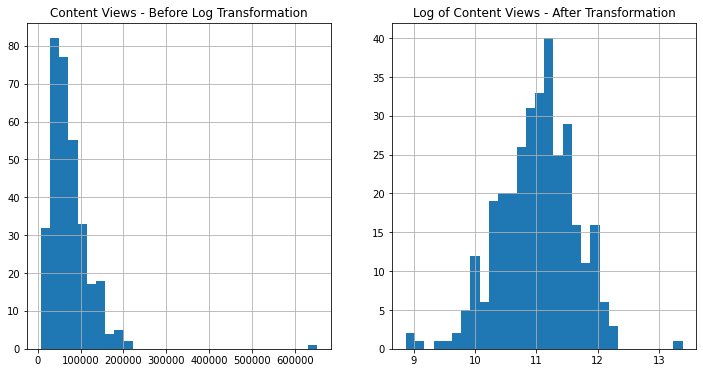

In [9]:
import matplotlib.pyplot as plt

# Before transformation
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
data['content_views'].hist(bins=30)
plt.title('Content Views - Before Log Transformation')

# After transformation
plt.subplot(1, 2, 2)
data['log_content_views'].hist(bins=30)
plt.title('Log of Content Views - After Transformation')
plt.show()

In [14]:
import pandas as pd
import numpy as np

# Load your cleaned dataset (replace with your actual file path)
data = pd.read_excel('cleaned_influencer_data.xlsx')  # Ensure this file path is correct

# Apply log transformation
data['log_content_views'] = np.log1p(data['content_views'])
data['log_total_impressions'] = np.log1p(data['total_impressions'])
data['log_total_paid_media_spend'] = np.log1p(data['total_paid_media_spend'])
data['log_total_posts'] = np.log1p(data['total_posts'])
data['log_views_per_post'] = np.log1p(data['views_per_post'])

# Check the summary statistics of the transformed data
print(data[['log_content_views', 'log_total_impressions', 'log_total_paid_media_spend', 
             'log_total_posts', 'log_views_per_post']].describe())



       log_content_views  log_total_impressions  log_total_paid_media_spend  \
count         326.000000             326.000000                  326.000000   
mean           11.012313              16.660518                    9.104512   
std             0.613230               0.994088                    1.084765   
min             8.867850              13.103497                    0.000000   
25%            10.599038              16.042214                    8.776050   
50%            11.069493              16.587945                    9.136317   
75%            11.426266              17.185500                    9.544256   
max            13.387327              19.734247                   12.113316   

       log_total_posts  log_views_per_post  
count       326.000000          326.000000  
mean          3.156628            7.907958  
std           0.563398            0.432455  
min           1.098612            6.077858  
25%           2.833213            7.650479  
50%           3.13

In [16]:

import numpy as np

# Load your dataset (replace with your actual file)
data = pd.read_excel('cleaned_influencer_data.xlsx')

# Apply log transformation to the relevant variables
data['log_total_impressions'] = np.log(data['total_impressions'])
data['log_total_posts'] = np.log(data['total_posts'])
data['log_total_engagement'] = np.log(data['total_engagement'])

# Drop original columns that have been transformed
data = data.drop(columns=['total_impressions', 'total_posts','total_engagement'])

# Save the cleaned DataFrame with transformed variables
data.to_excel('log_transformation_cleaned_data.xlsx', index=False)


In [21]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_excel('cleaned_influencer_data.xlsx')

# Define a function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    # Define bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filter out outliers
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers for relevant variables
data = remove_outliers(data, 'total_impressions')
data = remove_outliers(data, 'total_posts')
data = remove_outliers(data, 'total_engagement')

# Apply log transformation to the relevant variables
data['log_total_impressions'] = np.log(data['total_impressions'])
data['log_total_posts'] = np.log(data['total_posts'])
data['log_total_engagement'] = np.log(data['total_engagement'])

# Drop original columns that have been transformed
data = data.drop(columns=['total_impressions', 'total_posts','total_engagement'])

# Save the cleaned DataFrame with transformed variables
data.to_excel('log_transformation_cleaned_data.xlsx', index=False)


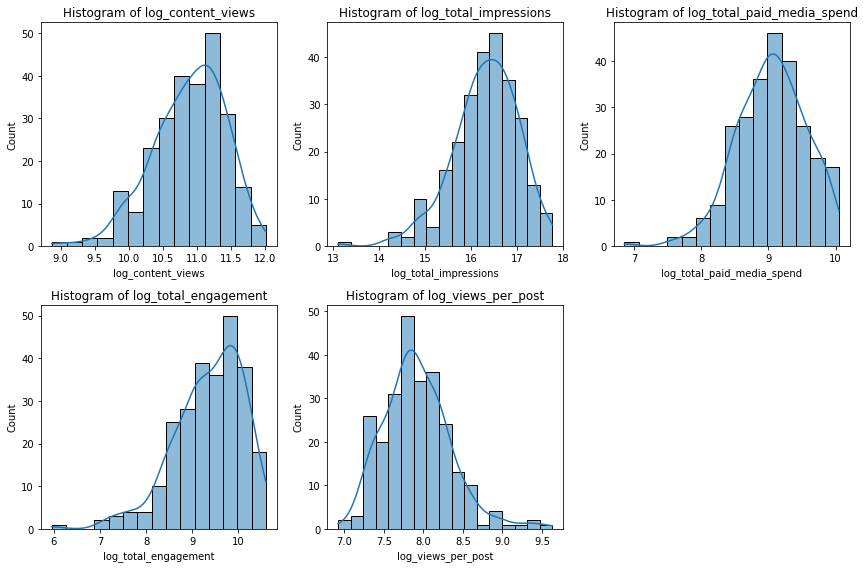

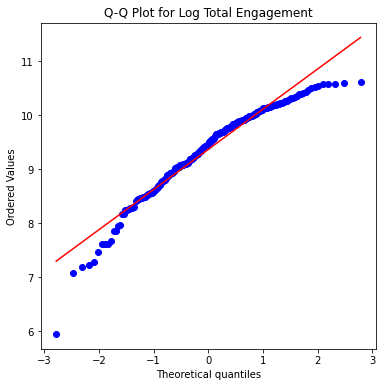

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Plot histograms
log_columns = ['log_content_views', 'log_total_impressions', 'log_total_paid_media_spend', 'log_total_engagement', 'log_views_per_post']

plt.figure(figsize=(12, 8))
for i, col in enumerate(log_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

# Q-Q plot for log_total_engagement
plt.figure(figsize=(6, 6))
stats.probplot(data['log_total_engagement'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Log Total Engagement')
plt.show()


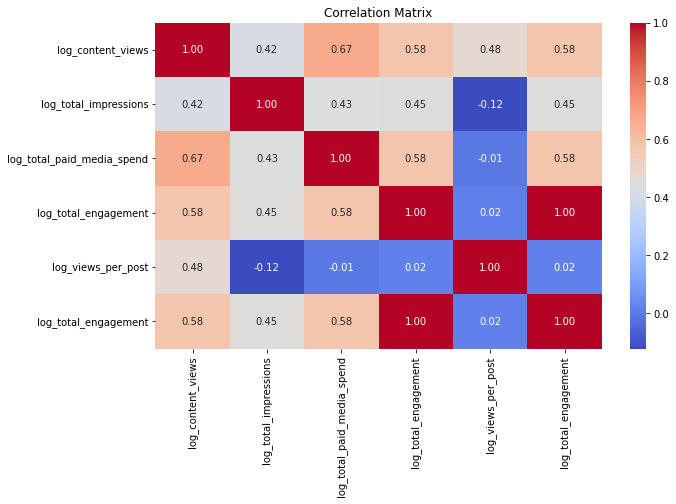

In [18]:
# Correlation matrix
correlation_matrix = data[log_columns + ['log_total_engagement']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [28]:
print(train_data.columns)


Index(['total_engagement', 'content_views', 'total_impressions', 'total_posts',
       'total_paid_media_spend', 'engagement_rate', 'views_per_post',
       'engagement_to_views_ratio', 'content_views_actual_vs_proj',
       'engagements_actual_vs_proj', 'total_media_value'],
      dtype='object')


In [2]:
import pandas as pd
import numpy as np

# Load your test dataset (replace with your actual file path)
test_data = pd.read_excel('CB_Business_Analytics_Test_Dataset.xlsx')

# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers for relevant variables in test dataset
for column in ['content_views', 'total_impressions', 'total_paid_media_spend', 'total_posts']:
    if column in test_data.columns:
        test_data = remove_outliers(test_data, column)

# Create missing variables in the test dataset
def create_missing_variables(test_df):
    # Create engagement_rate
    if 'total_engagement' in test_df.columns and 'content_views' in test_df.columns:
        test_df['engagement_rate'] = test_df['total_engagement'] / test_df['content_views']
    else:
        test_df['engagement_rate'] = np.nan  # Assign NaN if not calculable

    # Placeholder for predicted total_engagement
    test_df['total_engagement'] = np.nan

    # Create total_impressions based on total_posts
    if 'total_posts' in test_df.columns:
        test_df['total_impressions'] = test_df['total_posts'] * 1000  # Example estimation (modify as needed)

    return test_df

# Apply function to create missing variables
test_data = create_missing_variables(test_data)

# Apply log transformations to relevant variables
for column in ['content_views', 'total_impressions', 'total_paid_media_spend', 'total_posts']:
    if column in test_data.columns:
        test_data[f'log_{column}'] = np.log(test_data[column] + 1)  # Adding 1 to avoid log(0)

# Save the prepared test dataset
test_data.to_excel('prepared_test_dataset.xlsx', index=False)


In [4]:
import pandas as pd
import numpy as np

# Load your test dataset (replace with your actual file path)
test_data = pd.read_excel('CB_Business_Analytics_Test_Dataset.xlsx')
# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers for relevant variables in test dataset
for column in ['content_views', 'total_impressions', 'total_paid_media_spend', 'total_posts']:
    if column in test_data.columns:
        test_data = remove_outliers(test_data, column)

# Create missing variables in the test dataset
def create_missing_variables(test_df):
    # Create engagement_rate if total_engagement and content_views exist
    if 'total_engagement' in test_df.columns and 'content_views' in test_df.columns:
        test_df['engagement_rate'] = test_df['total_engagement'] / test_df['content_views']
    else:
        test_df['engagement_rate'] = np.nan  # Assign NaN if not calculable

    # Placeholder for predicted total_engagement
    test_df['total_engagement'] = np.nan  # Placeholder for actual total engagement values

    # Create total_impressions based on total_posts if total_posts exists
    if 'total_posts' in test_df.columns:
        test_df['total_impressions'] = test_df['total_posts'] * 1000  # Example estimation

    # Create content_views if missing
    if 'content_views' not in test_df.columns:
        test_df['content_views'] = np.random.randint(1000, 50000, size=len(test_df))  # Placeholder values

    return test_df

# Apply function to create missing variables
test_data = create_missing_variables(test_data)

# Apply log transformations to relevant variables
for column in ['content_views', 'total_impressions', 'total_paid_media_spend', 'total_posts']:
    if column in test_data.columns:
        test_data[f'log_{column}'] = np.log(test_data[column] + 1)  # Adding 1 to avoid log(0)

# Check the resulting DataFrame before saving
print(test_data.head())  # Display the first few rows for verification

# Save the prepared test dataset
test_data.to_excel('prepared_test_dataset.xlsx', index=False)


          Unnamed: 0 Campaign Details           Unnamed: 2  \
0  sofab_campaign_id        client_id           start_date   
1               1112               64  2016-02-17 00:00:00   
2               1949               80  2017-07-18 00:00:00   
3               1492              202  2016-09-15 00:00:00   
4               1811               11  2017-05-03 00:00:00   

            Unnamed: 3     Unnamed: 4         Unnamed: 5    Unnamed: 6  \
0             end_date       category            hashtag  product_type   
1  2016-09-20 00:00:00            HBA    #WhatMattersToU      Standard   
2  2017-10-06 00:00:00    Electronics   #SamsungUnlocked      Standard   
3  2017-02-06 00:00:00  Food/Beverage      #OREOThinSide      Standard   
4  2017-08-08 00:00:00  Food/Beverage  #MyMicheladaMatch      Standard   

  Unnamed: 7          Unnamed: 8 Unnamed: 9  ... Unnamed: 22     Unnamed: 23  \
0   retailer       sell_location     status  ...   tutorials  party_tutorial   
1    Walmart  Northwes

In [5]:
import pandas as pd

# Load your datasets
train_data = pd.read_excel('log_transformation_cleaned_data.xlsx')  # Your training dataset
test_data = pd.read_excel('prepared_test_dataset.xlsx')  # Your test dataset

# Copying variables from train to test
variables_to_copy = ['content_views', 'engagement_rate', 'total_engagement', 'total_impressions']

# Make sure the test dataset has NaN for the copied variables
for var in variables_to_copy:
    if var not in test_data.columns:
        test_data[var] = pd.Series([float('nan')] * len(test_data))

# You may want to compute engagement_rate from existing data in the test set if possible
# For example, if you have total_engagement and total_impressions in test, you can compute engagement_rate as:
if 'total_engagement' in test_data.columns and 'total_impressions' in test_data.columns:
    test_data['engagement_rate'] = test_data['total_engagement'] / test_data['total_impressions']

# Save the updated test dataset
test_data.to_excel('updated_test_dataset.xlsx', index=False)
